In [1]:
'''
WORKFLOW
Cleaning
1. Import site data
2. Take years that have beengapfilled, remove NA
3. Plot to check

Analysis
4. Select threshold limits and generate values
5. Get noise and switching rates at each threshold
6. Run methane model on noise
7. Store and group by threshld to get pdf

Export
8. Plot and save
'''

'\nWORKFLOW\nCleaning\n1. Import site data\n2. Take years that have beengapfilled, remove NA\n3. Plot to check\n\nAnalysis\n4. Select threshold limits and generate values\n5. Get noise and switching rates at each threshold\n6. Run methane model on noise\n7. Store and group by threshld to get pdf\n\nExport\n8. Plot and save\n'

In [37]:
'''Imports'''
#General python packages
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
from scipy import stats
import random

#For solving systems of equations
import sympy as sp
from sympy.solvers import solve

#Utils
from functions import *

def jitter(x, lim = 1):
    return [s + random.uniform(-lim, lim) for s in x]

In [3]:
'''Params'''
#Params
k_p = 2
k_ox = 1
k_om = 6
k_e = 0.2

k_max = 1
a_max = 1000

#Nondimensionalized
b = k_p/k_ox
g = k_p/k_om
e = k_e/k_max
a = 1/a_max

dt = 0.1

In [4]:

'''(1) Import Normalized Data'''
#site list: "CA-SCB", "DE-Hte", "DE-Zrk", "FI-Si2", "FI-Sii", "FR-LGt", "JP-BBY", "NZ-KOP", "SE-DEG"
sitename = "SE-DEG"
daily = pd.read_csv('data/cleaned/' + sitename + '_normalized.csv')

Text(0.5, 0.98, 'SE-DEG')

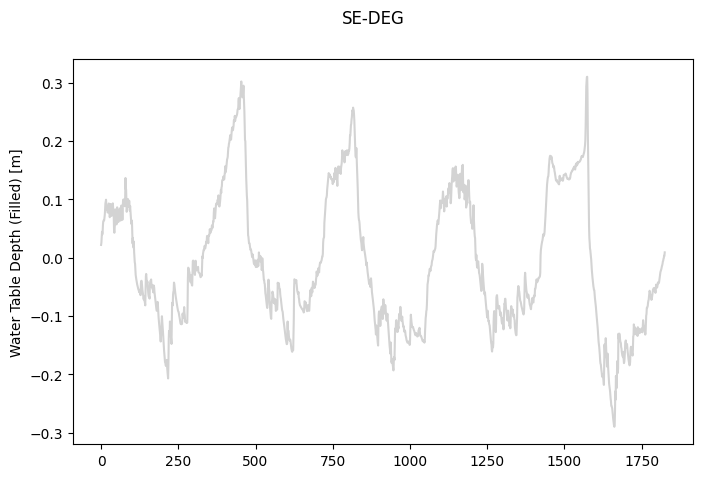

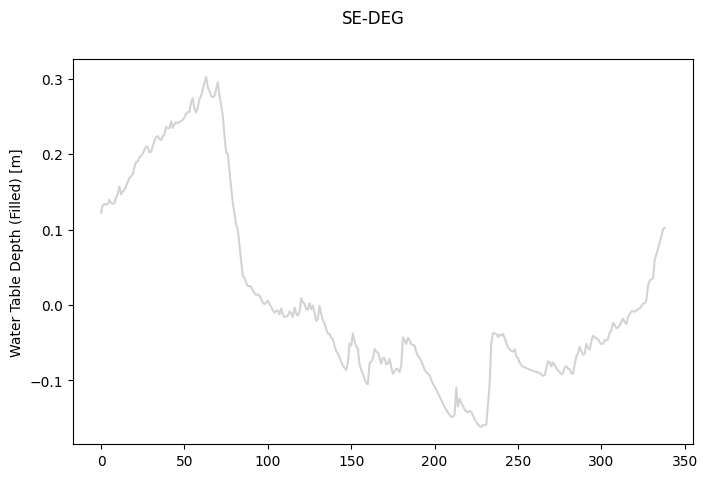

In [5]:
'''(2, 3) Select Data'''
fig, ax = plt.subplots(figsize = (8, 5))
plt.plot(daily.WTD_F, zorder = 5, color = 'lightgray')
ax.set(ylabel = 'Water Table Depth (Filled) [m]')
plt.suptitle(sitename)

#%%
#Select a bit of WTE data that contains no missing data. 
#   CA-SCB [516:1247]
#   DE-Hte [2188:2672]
#   DE-Zrk [1095:1576, 1660:2190]
#   FI-Si2 Do not use
#   FI-Sii Do not use
#   FR-LGt [238:407, 424:711]
#   JP-BBY [all]
#   NZ-NOP [all]
#   SE-SfN Do not use
#   SE-DEG [391:730]
WTD_sample = daily.WTD_F[391:730].dropna().reset_index(drop = True)
meth_sample = daily.FCH4_F_NORM[391:730].reset_index(drop = True)

fig, ax = plt.subplots(figsize = (8, 5))
plt.plot(WTD_sample, zorder = 5, color = 'lightgray')
#plt.plot(meth_sample, zorder = 5, color = 'black')
ax.set(ylabel = 'Water Table Depth (Filled) [m]')
plt.suptitle(sitename)

In [6]:
'''(4, 5) Pull switching rates from each of the chosen thresholds'''
nbin = 20
l_limit = -0.15 
u_limit = 0.3
#Redefine thresh to increase samples
#   CA-SCB np.linspace(-0.25, 0.05, 30)
#   JP-BBY np.linspace(-0.20, 0.15, 30)
#   NZ-KOP np.linspace(-0.25, -0.05, 30)
#   DE-Hte np.linspace(-0.6, -0.25, 30)
#   DE-Zrk np.linspace(-0.1, 0.4, 30)
#   FR-LGt np.linspace(-0.35, -0.15, 30)
#   SE-DEG np.linspace(-0.15, 0.3, 30)
thresh,depthStep = np.linspace(l_limit, u_limit, nbin, retstep = True)

#Rerun decomp
storage_N = pd.DataFrame(np.zeros((len(WTD_sample), len(thresh))))

#The probability of being in state 1 is k2/(k1+k2) and in state 2 is k1/(k1+k2)
k1_values = []
k2_values = []
crosses = []

for i in range(0, len(thresh)):
    #Threshold
    t = thresh[i]

    #Derive noise
    k1, k2, N = switch_param(WTD_sample, t)

    #Save derived noise
    storage_N[i] = N

    #Calculate crosses
    cross = ncrosses(WTD_sample.reset_index(drop=True), t)

    k1_values.append(k1)
    k2_values.append(k2)
    crosses.append(cross)

#Combine into a dataframe
derivedK = pd.DataFrame([thresh, k1_values, k2_values, crosses]).transpose()
derivedK.columns = ['thresholds', 'k1', 'k2', 'crosses']

In [7]:
'''(6) Run coupled methane/acetate simulation'''
#Use the switching rates previously derived

#Empty df for values
storage_thresh = pd.DataFrame({'Time' : [], 
                               'Noise' : [], 
                               'Acetate': [], 
                               'Methane' : [], 
                               'Emission' : [], 
                               'Threshold' : []})

for i in range(0, len(thresh)):
    noise = pd.DataFrame({'x' : np.array(range(0, len(WTD_sample))),
                         'noise' : np.array(storage_N[i])})
    
    noise_resampled = downsample(noise, 'x', dt)

    #Run numerical solution
    s = rk4_solve_ma(0.5, 0.5, 0.1, noise_resampled,
                     kp = k_p, kox = k_ox, kom = k_om, e = e)
    
    s['Threshold'] = thresh[i]

    #Concat
    storage_thresh = pd.concat((storage_thresh, s))

c:\Users\mwjones\OneDrive - DOI\Desktop\Projects\PAUSED - Critical Wetland Inundation\dichotomous\functions.py:138: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  s.Acetate[0], s.Methane[0],  = a_init, m_init
c:\Users\mwjones\OneDrive - DOI\D

In [8]:
'''(6.5) Linear composition of methane emissions to simulate total emissions signature across all thresholds'''

#Round timestamp and aggregate
storage_thresh['Day'] = np.floor(storage_thresh.Time)
storage_accumulation = storage_thresh.groupby(['Day', 'Threshold']).mean().reset_index(drop = False)

#reshape 
storage_thresh_reshaped = storage_accumulation.pivot(columns = 'Threshold', values = 'Emission') 

storage_thresh_reshaped['Accumulated'] = storage_thresh_reshaped.sum(axis = 1, skipna = True)

#Plot simulated methane emission trace against measured methane trace
#fig, ax = plt.subplots(1, 1, figsize=(5, 3))

#plt.plot(np.cumsum(meth_sample), color = 'lightgray')
#ax.set_ylabel("Cumulative Turbulent Ch4 Flux (Measured, Filled) [m day-1]")

#ax2 = ax.twinx()
#plt.plot(storage_thresh_reshaped.Accumulated, color = 'blue')
#ax2.set_ylabel(r'Estimated Cumulative $\frac{dE}{dt}$', color = 'blue')
#ax.set_xlabel('Time')

#plt.savefig("figures/sites/" + sitename + "_methanecomparison.pdf", bbox_inches = 'tight')
#plt.show() 
storage_thresh

,Time,Noise,Acetate,Methane,Emission,Threshold,Day
0,0.0,1.0,0.500000,5.000000e-01,0.000000,-0.15,0.0
1,0.1,1.0,0.454546,5.454544e-01,0.000000,-0.15,0.0
2,0.2,1.0,0.416667,5.833331e-01,0.000000,-0.15,0.0
3,0.3,1.0,0.384616,6.153844e-01,0.000000,-0.15,0.0
4,0.4,1.0,0.357143,6.428569e-01,0.000000,-0.15,0.0
...,...,...,...,...,...,...,...
3376,337.6,-1.0,1.000000,1.363740e-16,0.291666,0.30,337.0
3377,337.7,-1.0,1.000000,1.363740e-16,0.291666,0.30,337.0
3378,337.8,-1.0,1.000000,1.363740e-16,0.291666,0.30,337.0
3379,337.9,-1.0,1.000000,1.363740e-16,0.291666,0.30,337.0


In [23]:
'''TEST (7) Groupby day (time step) to get total daily emission from all threshold crossings'''
thresh_daily_pdf = storage_thresh.groupby('Day').sum().reset_index()
thresh_daily_pdf['Emission_converted'] = thresh_daily_pdf.Emission*1000*(depthStep)*(1/dt)
thresh_daily_pdf['Emission_converted_uncum'] = np.diff(thresh_daily_pdf.Emission_converted, prepend=thresh_daily_pdf.Emission_converted[0])
thresh_daily_pdf.drop(thresh_daily_pdf.tail(1).index, inplace = True)
thresh_daily_pdf

,Day,Time,Noise,Acetate,Methane,Emission,Threshold,Emission_converted,Emission_converted_uncum
0,0.0,90.0,40.0,114.271493,105.523275,2.837605,15.0,672.064337,0.000000
1,1.0,290.0,40.0,104.812676,108.038228,6.781728,15.0,1606.198625,934.134287
2,2.0,490.0,40.0,97.513306,108.270893,8.553937,15.0,2025.932339,419.733714
3,3.0,690.0,40.0,93.539742,109.059291,9.350242,15.0,2214.530909,188.598570
4,4.0,890.0,48.0,90.221420,110.951927,9.706663,15.0,2298.946581,84.415672
...,...,...,...,...,...,...,...,...,...
333,333.0,66690.0,0.0,108.995493,92.367594,96.688775,15.0,22899.972979,0.000000
334,334.0,66890.0,0.0,106.469197,94.893889,96.688775,15.0,22899.972979,0.000000
335,335.0,67090.0,8.0,104.522173,96.840914,96.688775,15.0,22899.972979,0.000000
336,336.0,67290.0,20.0,98.576464,102.786623,96.688775,15.0,22899.972979,0.000000


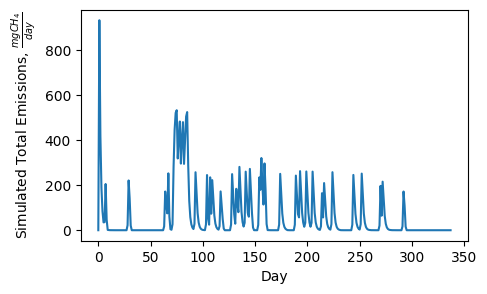

NameError: name 'calc_corr' is not defined

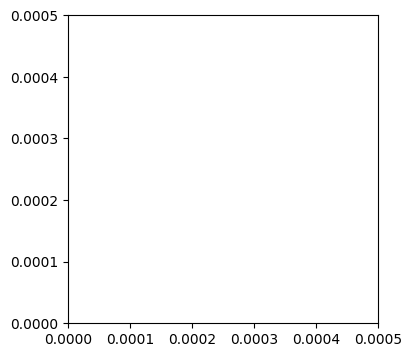

In [38]:

#%%
'''(8) Plot'''
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

ax.plot(thresh_daily_pdf.Day, thresh_daily_pdf.Emission_converted_uncum)

#ax.set_xlim(l_limit, u_limit)
ax.set_xlabel('Day')
ax.set_ylabel(r'Simulated Total Emissions, $\frac{mgCH_4}{day}$')

plt.savefig("figures/sites/" + sitename + "_emissions.pdf", bbox_inches = 'tight')
plt.show() 


fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.scatter(x = meth_sample[0:-1], y = thresh_daily_pdf.Emission_converted_uncum, 
        alpha = 0.7,
        marker = 'o')

ax.set_xlim(0, 5e-4)
ax.set_ylim(0, 5e-4)

r2, p = calc_corr(meth_sample[0:-1], thresh_daily_pdf.Emission_converted_uncum)
ax.title(r'$R^2$: ' + str(round(r2, 2)) + r'$p$: ' + str(round(p, 3)), size = 'small', loc = 'left')

#ax.set_xlim(-0.25, 0.05)
ax.set_xlabel(r'Measured Daily Methane Flux, $\frac{mgCH_4}{day}$')
ax.set_ylabel(r'Simulated Total Emissions, $\frac{mgCH_4}{day}$')

plt.savefig("figures/sites/" + sitename + "_model_data_comparison.pdf", bbox_inches = 'tight')
plt.show() 
